In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interact_manual
from copy import deepcopy
from tqdm.notebook import tqdm
import networkx as nx


F = A * N_w * N_s
A = M * M = c^2 * 

In [8]:
# given topic number, assign proper probability according to zipf's distribution with alpha = 1
def freq_dist(topic_num, const=1):
    prob = [1/(i+1) for i in range(topic_num)]
    # get normalized probability
    prob = [np.round(i/sum(prob) * const) for i in prob]
    return np.array(prob)

def weight_dist(topic_num):
    weight = np.random.normal(0.3, 0.1, (topic_num, topic_num))
    for i in range(topic_num):
        weight[i, i] = 0
    np.clip(weight, 0, 1, out=weight)
    return weight

# given list A, return all pairs of objects
def get_pairs(A):
    return [(A[i], A[j]) for i in range(len(A)) for j in range(i+1, len(A))]

In [9]:
class topic_space:
    def __init__(self, dim, topic_num, frequency=None, weight=None):
        self.dim = dim
        self.topic_num = topic_num
        self.scale_const = 5  # N_w
        self.magnitude_const = 1  # N_e
        self.freq_const = 1000 # N_f
        
        # sample topic frequency from a zipf distribution
        if frequency is None:
            self.frequency = freq_dist(topic_num, self.freq_const) 
        else:
            self.frequency = frequency
            
        if weight is None:
            self.weight = weight_dist(topic_num)
        else:
            self.weight = weight
        
    def copy_from(self, topic_space):
        self.frequency = deepcopy(topic_space.frequency)
        self.weight = deepcopy(topic_space.weight)
    
    # Frequency
    
    def perturb_frequency(self, perturbation):
        assert perturbation.shape == self.frequency.shape
        self.frequency += perturbation
        np.clip(self.frequency, 0, None, out=self.frequency)
        
    def perturb_frequency_gaussian(self, std):
        perturbation = np.round(np.random.normal(0, std, self.frequency.shape))
        self.perturb_frequency(perturbation)
    
    # Edge weights (similarity)
    
    def perturb_weight(self, perturbation):
        assert perturbation.shape == self.weight.shape
        for i in range(self.topic_num):
            assert perturbation[i, i] == 0
        self.weight += perturbation
        np.clip(self.weight, 0, 1, out=self.weight)
        
    def perturb_weight_gaussian(self, std):
        perturbation = np.random.normal(0, std, self.weight.shape)
        for i in range(self.topic_num):
            perturbation[i, i] = 0
        self.perturb_weight(perturbation)
        
    def update_weight(self, topic_id1, topic_id2, w):
        self.weight[topic_id1, topic_id2] = w
        self.weight[topic_id2, topic_id1] = w
  
    # Events
    
    def generate_events(self, event_num, event_topic_num):
        events = np.zeros((event_num, event_topic_num)).astype(int)
        for i in range(event_num):
            # first, sample event according to its frequency
            events[i][0] = np.random.choice(self.topic_num, p=self.frequency/np.sum(self.frequency))
            # then, sample the rest of the event according to the sum of the weight 
            for j in range(1, event_topic_num):
                weight = self.weight[events[i, :j], :]
                weight = np.sum(weight, axis=0)
                weight[events[i, :j]] = 0
                weight = weight / np.sum(weight)
                events[i, j] = np.random.choice(self.topic_num, p=weight)
        
        return events

    def get_magnitudes(self, events):
        event_num = events.shape[0]
        event_topic_num = events.shape[1]
        magnitudes = []
        for event in events:
            log_freq_sum = np.sum(np.log(1 + np.array([self.frequency[i] for i in event])))
            magnitudes.append((self.magnitude_const / event_topic_num) * log_freq_sum)
        return np.array(magnitudes)

    # Activity generation
    
    def activity_graph_generation(self):
        activity_graph = nx.Graph()
        activity_graph.add_nodes_from(range(self.topic_num))

        nx.set_node_attributes(activity_graph, 0, 'visited')
        for i in range(self.topic_num):
            for j in range(self.topic_num):
                activity_graph.add_edge(i, j, passed=0)
                
        return activity_graph
        
    def activity_generation(self, events, articles, step_num, modifier):
        
        activity_graph = self.activity_graph_generation()
        
        for i, article_num in enumerate(articles):
            topic_num = self.topic_num
            event = events[i]
            freq_list = np.array([self.frequency[t] for t in event])
            mod_weight = deepcopy(self.weight)
            
            # for all pairs in events[i], add modifier to the weight
            for (a, b) in get_pairs(event):
                mod_weight[a, b] *= (1 + modifier)
            
            for j in range(article_num):
                walker_num = np.round(self.scale_const * (freq_list/np.sum(freq_list))).astype(int)
                for n, k in enumerate(walker_num):
                    current = event[n]
                    activity_graph.nodes[current]['visited'] += 1
                    for r in range(step_num):
                        next = np.random.choice(a=topic_num, p=mod_weight[current]/np.sum(mod_weight[current]))
                        activity_graph.nodes[next]['visited'] += 1
                        activity_graph.edges[next, current]['passed'] += 1
                        current = next
                                
        return activity_graph

### 1. Generate topic spaces

In [10]:
def generate_topic_spaces(dim, topic_num, comm_num, std):
    
    # generate general topic space
    
    general = topic_space(dim=dim, topic_num=topic_num)
    community_list = []
    
    # generate community topic spaces and perturb their embeddings from general topic space
    for i in range(comm_num):
        community_list.append(topic_space(dim=dim, topic_num=topic_num))
        community_list[i].copy_from(general)
        community_list[i].perturb_weight_gaussian(std=std)
        community_list[i].perturb_frequency_gaussian(std=std*100)
        
    return general, community_list

In [11]:
dim = 32
topic_num = 100
std = 0.1
comm_num = 5

general, community_list = generate_topic_spaces(dim=dim, topic_num=topic_num, comm_num=comm_num, std=std)

In [ ]:
general.

(array([ 798., 1372., 2237., 2492., 1776.,  933.,  314.,   62.,   11.,
           5.]),
 array([0.        , 0.09166603, 0.18333206, 0.27499809, 0.36666412,
        0.45833015, 0.54999619, 0.64166222, 0.73332825, 0.82499428,
        0.91666031]),
 <BarContainer object of 10 artists>)

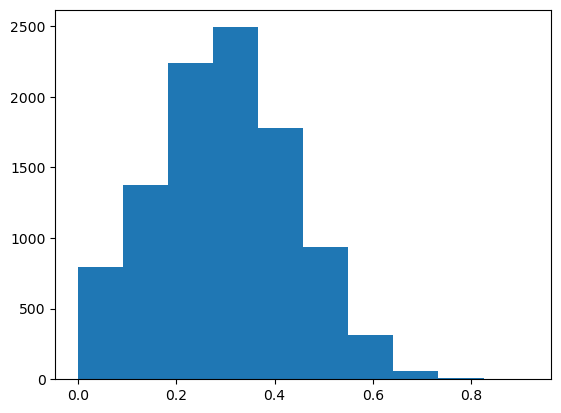

In [7]:
plt.hist(community_list[0].weight.flatten())

### 2. Event generation & Filter → Article generation

In [8]:
events = general.generate_events(event_num=100, event_topic_num=3)

In [9]:
x = general.get_magnitudes(events)
mag_list = np.zeros((len(community_list), len(events)))
for i in range(len(community_list)):
    mag_list[i] = community_list[i].get_magnitudes(events)

In [10]:
def event_generation(general, community_list, event_num, event_topic_num):
    
    # generate events
    events = general.generate_events(event_num=event_num, event_topic_num=event_topic_num)
    
    general_mag = general.get_magnitudes(events)
    mag_list = np.zeros((len(community_list), len(events)))
    for i in range(len(community_list)):
        mag_list[i] = community_list[i].get_magnitudes(events)
    
    return events, np.round(general_mag * mag_list).astype(int)
    


In [11]:
event_num = 100
event_topic_num = 3

events, articles = event_generation(general=general, community_list=community_list, event_num=event_num, event_topic_num=event_topic_num)

### 3. Activity generation

In [45]:
step_num = 10
modifier = 1000
activity_graph_list = []
for i in range(len(community_list)):
    activity_graph_list.append(community_list[i].activity_generation(events=events, articles=articles[i], step_num=step_num, modifier=modifier))

(array([1200.,  873., 1006., 1011.,  962., 1013.,  967., 1037.,  869.,
        1062.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

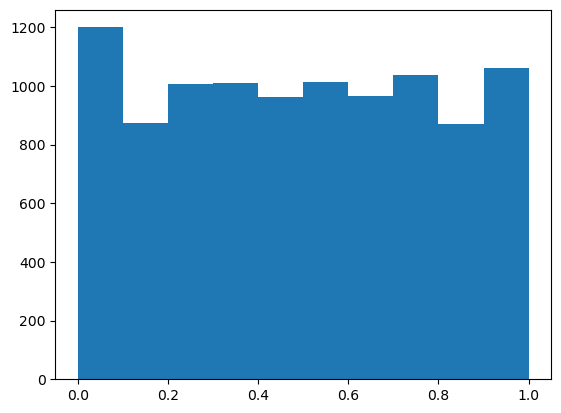

In [50]:
plt.hist(community_list[0].weight.flatten())

In [25]:
# get all 'visited' from graph
def get_visited(activity_graph):
    visited = []
    for i in range(topic_num):
        visited.append(activity_graph.nodes[i]['visited'])
    return np.array(visited)

# get all'passed' from graph in a matrix
def get_passed(activity_graph):
    passed = np.zeros((topic_num, topic_num))
    for i in range(topic_num):
        for j in range(topic_num):
            passed[i, j] = activity_graph.edges[i, j]['passed']
    return passed

(array([78.,  9.,  5.,  1.,  2.,  1.,  0.,  1.,  0.,  1.,  0.,  0.,  0.,
         0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([  2.        ,   8.36666667,  14.73333333,  21.1       ,
         27.46666667,  33.83333333,  40.2       ,  46.56666667,
         52.93333333,  59.3       ,  65.66666667,  72.03333333,
         78.4       ,  84.76666667,  91.13333333,  97.5       ,
        103.86666667, 110.23333333, 116.6       , 122.96666667,
        129.33333333, 135.7       , 142.06666667, 148.43333333,
        154.8       , 161.16666667, 167.53333333, 173.9       ,
        180.26666667, 186.63333333, 193.        ]),
 <BarContainer object of 30 artists>)

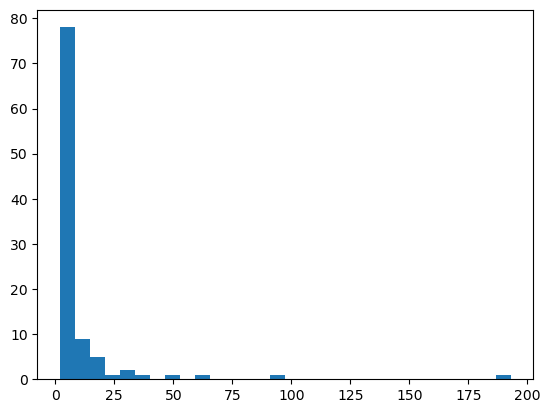

In [26]:
plt.hist(general.frequency, bins=30)

(array([ 2.,  3., 12., 10., 14., 17.,  8., 13.,  6.,  6.,  4.,  0.,  0.,
         2.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([131.        , 138.76666667, 146.53333333, 154.3       ,
        162.06666667, 169.83333333, 177.6       , 185.36666667,
        193.13333333, 200.9       , 208.66666667, 216.43333333,
        224.2       , 231.96666667, 239.73333333, 247.5       ,
        255.26666667, 263.03333333, 270.8       , 278.56666667,
        286.33333333, 294.1       , 301.86666667, 309.63333333,
        317.4       , 325.16666667, 332.93333333, 340.7       ,
        348.46666667, 356.23333333, 364.        ]),
 <BarContainer object of 30 artists>)

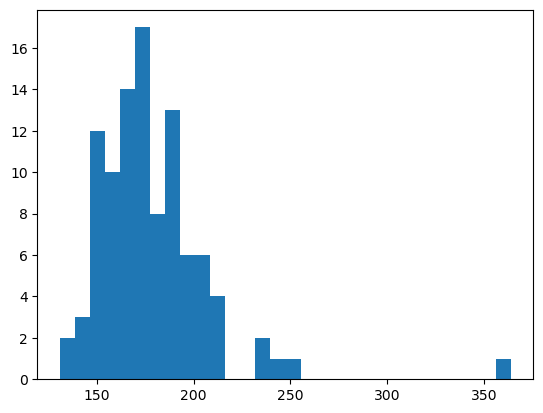

In [40]:
plt.hist(get_visited(activity_graph_list[0]), bins=30)

(array([ 2.,  4.,  5.,  9., 10.,  9., 16.,  5.,  8.,  8.,  7.,  2.,  3.,
         1.,  1.,  2.,  0.,  1.,  2.,  2.,  0.,  1.,  1.,  0.,  0.,  0.,
         0.,  0.,  0.,  1.]),
 array([121. , 128.3, 135.6, 142.9, 150.2, 157.5, 164.8, 172.1, 179.4,
        186.7, 194. , 201.3, 208.6, 215.9, 223.2, 230.5, 237.8, 245.1,
        252.4, 259.7, 267. , 274.3, 281.6, 288.9, 296.2, 303.5, 310.8,
        318.1, 325.4, 332.7, 340. ]),
 <BarContainer object of 30 artists>)

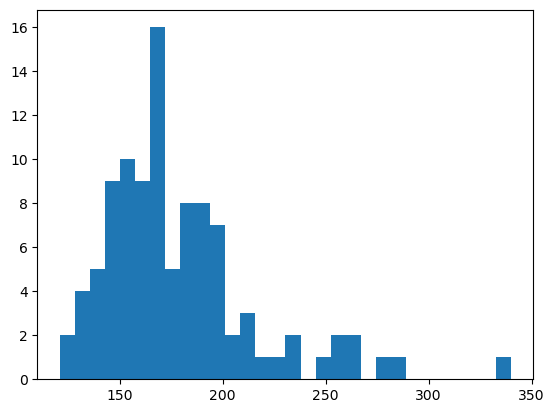

In [46]:
plt.hist(get_visited(activity_graph_list[0]), bins=30)

### 4. Topic embeddings / frequency change

### 5. Main

In [ ]:
dim = 16
topic_num = 100
std = 0.1
comm_num = 5
event_num = 1000
event_topic_num = 3
step_num = 10
timestep = 20


general, community_list = generate_topic_spaces(dim=dim, topic_num=topic_num, comm_num=comm_num, std=std)
activity_graph_list = []
for t in tqdm(range(timestep)):
    events, event_filter = event_generation(general=general, community_list=community_list, event_num=event_num, event_topic_num=event_topic_num, prob_func=myprob)
    activity_graph_list.append([])

    for i, community in enumerate(community_list):
        events_eff = events[event_filter[i].nonzero()[0]]
        activity_graph_list[-1].append(community.activity_generation(events=events_eff, step_num=step_num))

  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\Seungwoong\AppData\Local\Temp\ipykernel_168952\360853766.py:81: RuntimeWarning: divide by zero encountered in divide
  dist = 1 / dist
C:\Users\Seungwoong\AppData\Local\Temp\ipykernel_168952\360853766.py:16: RuntimeWarning: divide by zero encountered in divide
  inv_dist = 1 / self.dist
